In [ ]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 37.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import scipy.cluster.hierarchy as sch
import statsmodels.stats.multitest as ssm
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import time

from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
cohort = "immu"  # "synergy" or "immu"

expr_file = f"{cohort}_expression_filtered.tsv"
sigma_file = f"{cohort}_signatures_filtered.tsv"

prefix = f"{cohort}_"

In [ ]:
brca_expr_df = pd.read_csv(expr_file, sep="\t", index_col=0)
sigma_count_df = pd.read_csv(sigma_file, sep="\t", index_col=0)

brca_expr_genes = brca_expr_df.index

print(brca_expr_df.shape)
print(sigma_count_df.shape)
print(brca_expr_df.columns.equals(sigma_count_df.columns))

(32597, 34)
(6, 34)
True


# Compute correlation

In [ ]:
def comp_corr(x_col, y_col, nan_th=30):
    """
    compute correlation of x_col  and y_col
    x_col: expression
    y_col: sig count
    nan_th: allow some NaN as long as valid elements > nan_th
    """
    if (~x_col.isnull()).sum() >= nan_th:
        corr, pv = ss.spearmanr(x_col, y_col, nan_policy='omit')
    else:
        corr, pv = 0, 1 # if not enough samples
    return corr, pv

def comp_corr_all(x_df, y_df):
    """
    spearman correlation between gene expression and signatures

    :param x_df: gene expression DataFrame : samples (rows) X genes (columns)
    :param y_df: signature DataFrame: samples (rows) X signatures (columns)
    :return: corr_df (x*y)
    """
    # compute correlation
    corr_df = pd.DataFrame(index=x_df.columns, columns=y_df.columns)
    pv_df = pd.DataFrame(index=x_df.columns, columns=y_df.columns)
    for j in range(y_df.shape[1]):
        print(y_df.columns[j])
        corr_results = [comp_corr(x_df.iloc[:,i], y_df.iloc[:, j]) for i in range(x_df.shape[1])]
        # print(corr_results)
        corr_list, pv_list = tuple(zip(*corr_results))
        corr_df.iloc[:,j] = corr_list
        pv_df.iloc[:,j] = pv_list
    return corr_df, pv_df

In [ ]:
print(brca_expr_df.T.shape)

(34, 32597)


In [ ]:
print(sigma_count_df.T.shape)

(34, 6)


In [ ]:
sigs_of_interest = ["SBS1", "SBS2", "SBS5", "SBS13", "SBS39"]

corr_df, pv_df = comp_corr_all(brca_expr_df.T, sigma_count_df.T[sigs_of_interest])

corr_df.index = brca_expr_genes
pv_df.index = brca_expr_genes

SBS1
SBS2
SBS5
SBS13
SBS39


In [ ]:
corr_df.to_csv(f"{prefix}corr_expr_sigma_count.tsv", sep="\t")
pv_df.to_csv(f"{prefix}corr_pv_expr_sigma_count.tsv", sep="\t")

# Correlation analysis




In [ ]:
corr_count = corr_df.copy()
pv_count = pv_df.copy()

In [ ]:
print(list(corr_count.columns))

['SBS1', 'SBS2', 'SBS5', 'SBS13', 'SBS39']


In [ ]:
# select genes based on pvalues and correlation
# threshold for correlation coefs and p-values

# we filter for genes with significant correlation with at least one signature
corr_th = 0.3
#fdr_th = 0.005
fdr_th = 0.3

sig_corr_dic = {}
sig_corr_genes = set([])

sigs = list(corr_count.columns)

for sig in sigs:
    print(sig)
    rej, pvc, a, b = ssm.multipletests(pv_count[sig], fdr_th, method="fdr_bh")
    sig_corr = pv_count.index[rej & ((corr_count[sig] >= corr_th)|(corr_count[sig] <= -corr_th))]
    print(len(sig_corr))
    if len(sig_corr) == 0:
        continue
    sig_corr_dic[sig] = sig_corr
    sig_corr_genes = sig_corr_genes.union(sig_corr)

print("\nTotal:", len(sig_corr_genes))

SBS1
0
SBS2
2
SBS5
9
SBS13
1
SBS39
674

Total: 686


In [ ]:
genes_of_interest = sig_corr_genes

def create_corr_dic(corr_df, genes_of_interest):
    corr_subset = corr_df[corr_df.index.isin(genes_of_interest)]
    return corr_subset

corr_count_selected = create_corr_dic(corr_count, genes_of_interest)

print(corr_count_selected)

                SBS1      SBS2      SBS5     SBS13     SBS39
Name                                                        
LAS1L       0.205698  0.006263  0.332773   0.03198 -0.463035
IBTK       -0.035381 -0.051175 -0.254968  -0.14295  0.464466
TMEM98     -0.193905 -0.093046 -0.153164 -0.147843  0.533886
DNAJC11     0.159443  0.267329   0.11067  0.232424  -0.54301
CELSR3      0.309083  0.095551  0.285234  0.196075 -0.460351
...              ...       ...       ...       ...       ...
FRG2EP      0.075942  -0.05236  0.251292  0.007457  0.550811
CEP192P1   -0.106194  0.083046  0.075053  0.004698  0.509866
BCRP3       0.191454  0.319578  0.211862  0.240638 -0.588992
LINC01226   0.294073 -0.039366  0.310761 -0.150289  -0.47878
SAMD4A-AS1 -0.125035 -0.190952 -0.007204 -0.042126  0.478106

[686 rows x 5 columns]


In [ ]:
matrix_to_cluster = corr_count_selected
subset_genes = list(corr_count.index)

denom = 10
step = 5

In [ ]:
labels_all = []

# Fill NaN values with 0 before clustering
#matrix_to_cluster = matrix_to_cluster.fillna(0)

for ri in range(100):
    if ri%10 == 0:
        print(ri)
    clusterer_ri = MiniBatchKMeans(n_clusters=(int(ri/denom)+1)*step, random_state=ri)
    labels = clusterer_ri.fit_predict(matrix_to_cluster)
    labels_all.append(labels)

labels_df = pd.DataFrame(labels_all, columns=matrix_to_cluster.index)


0
10
20
30
40
50
60
70
80
90


In [ ]:
# find consensus score for each
def count_consensus(df, label):
    return (df == label).astype(int).sum(1)

consensus_df = pd.DataFrame()
labels_T = labels_df.T

# i added this:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=pd.errors.PerformanceWarning)

    for i in range(labels_df.shape[1]):
        if (i%1000==0): # print progress
            print(i)
        consensus_df[i] = count_consensus(labels_T, labels_T.iloc[i,:])

consensus_df.columns=consensus_df.index
consensus_df.to_csv(f"{prefix}corr_consensus.tsv", sep="\t")

0


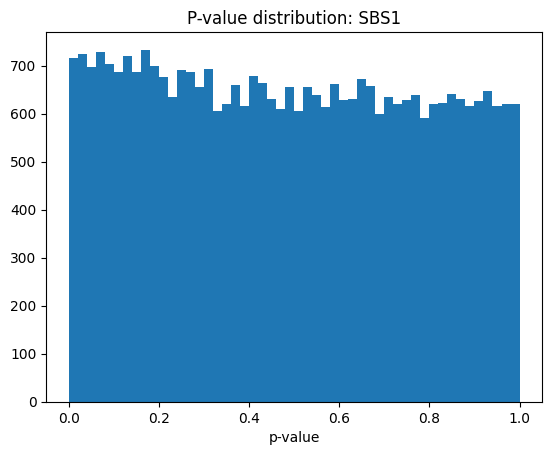

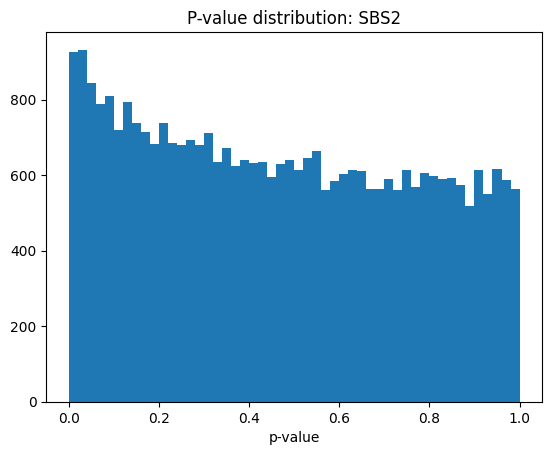

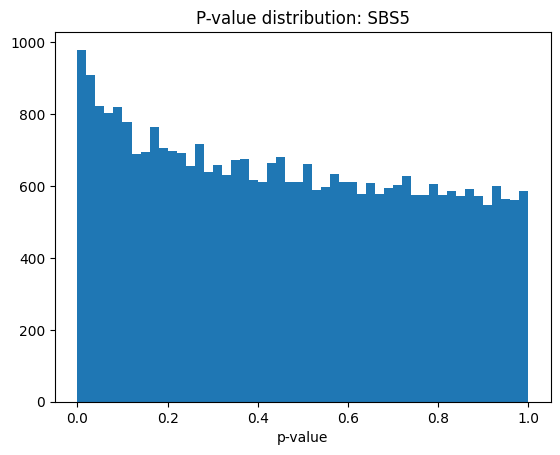

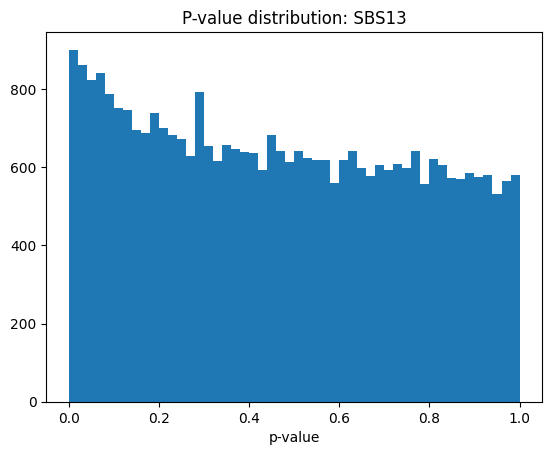

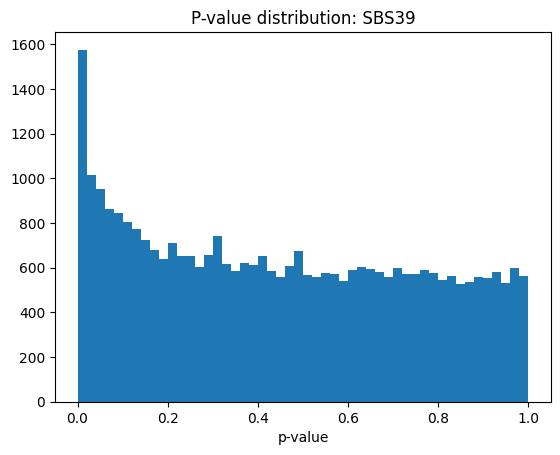

In [ ]:
for sig in sigs:
    plt.figure()
    plt.hist(pv_count[sig], bins=50)
    plt.title(f'P-value distribution: {sig}')
    plt.xlabel('p-value')
    plt.show()

In [ ]:
# hierarchical clustering

#consensus_mat = consensus_df.as_matrix() # no longer works
consensus_mat = consensus_df.to_numpy()
link_matrix = sch.linkage(consensus_mat, method="complete", metric="cosine")
# cluster_id_df = pd.DataFrame(index=matrix_to_cluster.index)
# nrange = range(7, 8)
# for n_clusters in nrange:
#     print(n_clusters)
#     th = [x[2] for x in link_matrix][-n_clusters]
#     labels = sch.fcluster(link_matrix, th, criterion='distance')
#     cluster_id_df["k="+str(n_clusters)] = labels

In [ ]:
silhouette_scores = {}

for k in range(2, 11):
    th = [x[2] for x in link_matrix][-k]
    labels = sch.fcluster(link_matrix, th, criterion="distance")

    score = silhouette_score(consensus_mat, labels, metric="cosine")
    silhouette_scores[k] = score

    print(f"k={k}: {score:.3f}")

k=2: 0.341
k=3: 0.232
k=4: 0.272
k=5: 0.351
k=6: 0.363
k=7: 0.412
k=8: 0.413
k=9: 0.395
k=10: 0.384


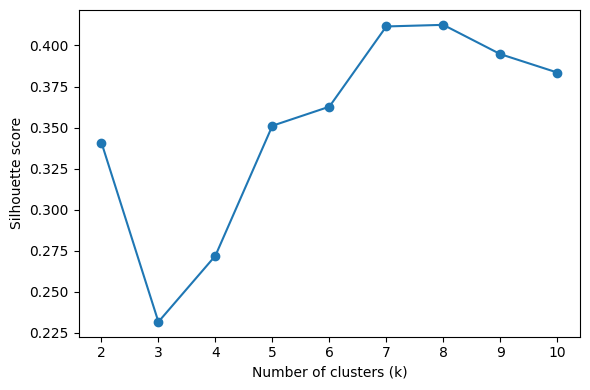

Best k: 8
Silhouette score: 0.4125466228038055


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

best_k = max(silhouette_scores, key=silhouette_scores.get)

print("Best k:", best_k)
print("Silhouette score:", silhouette_scores[best_k])

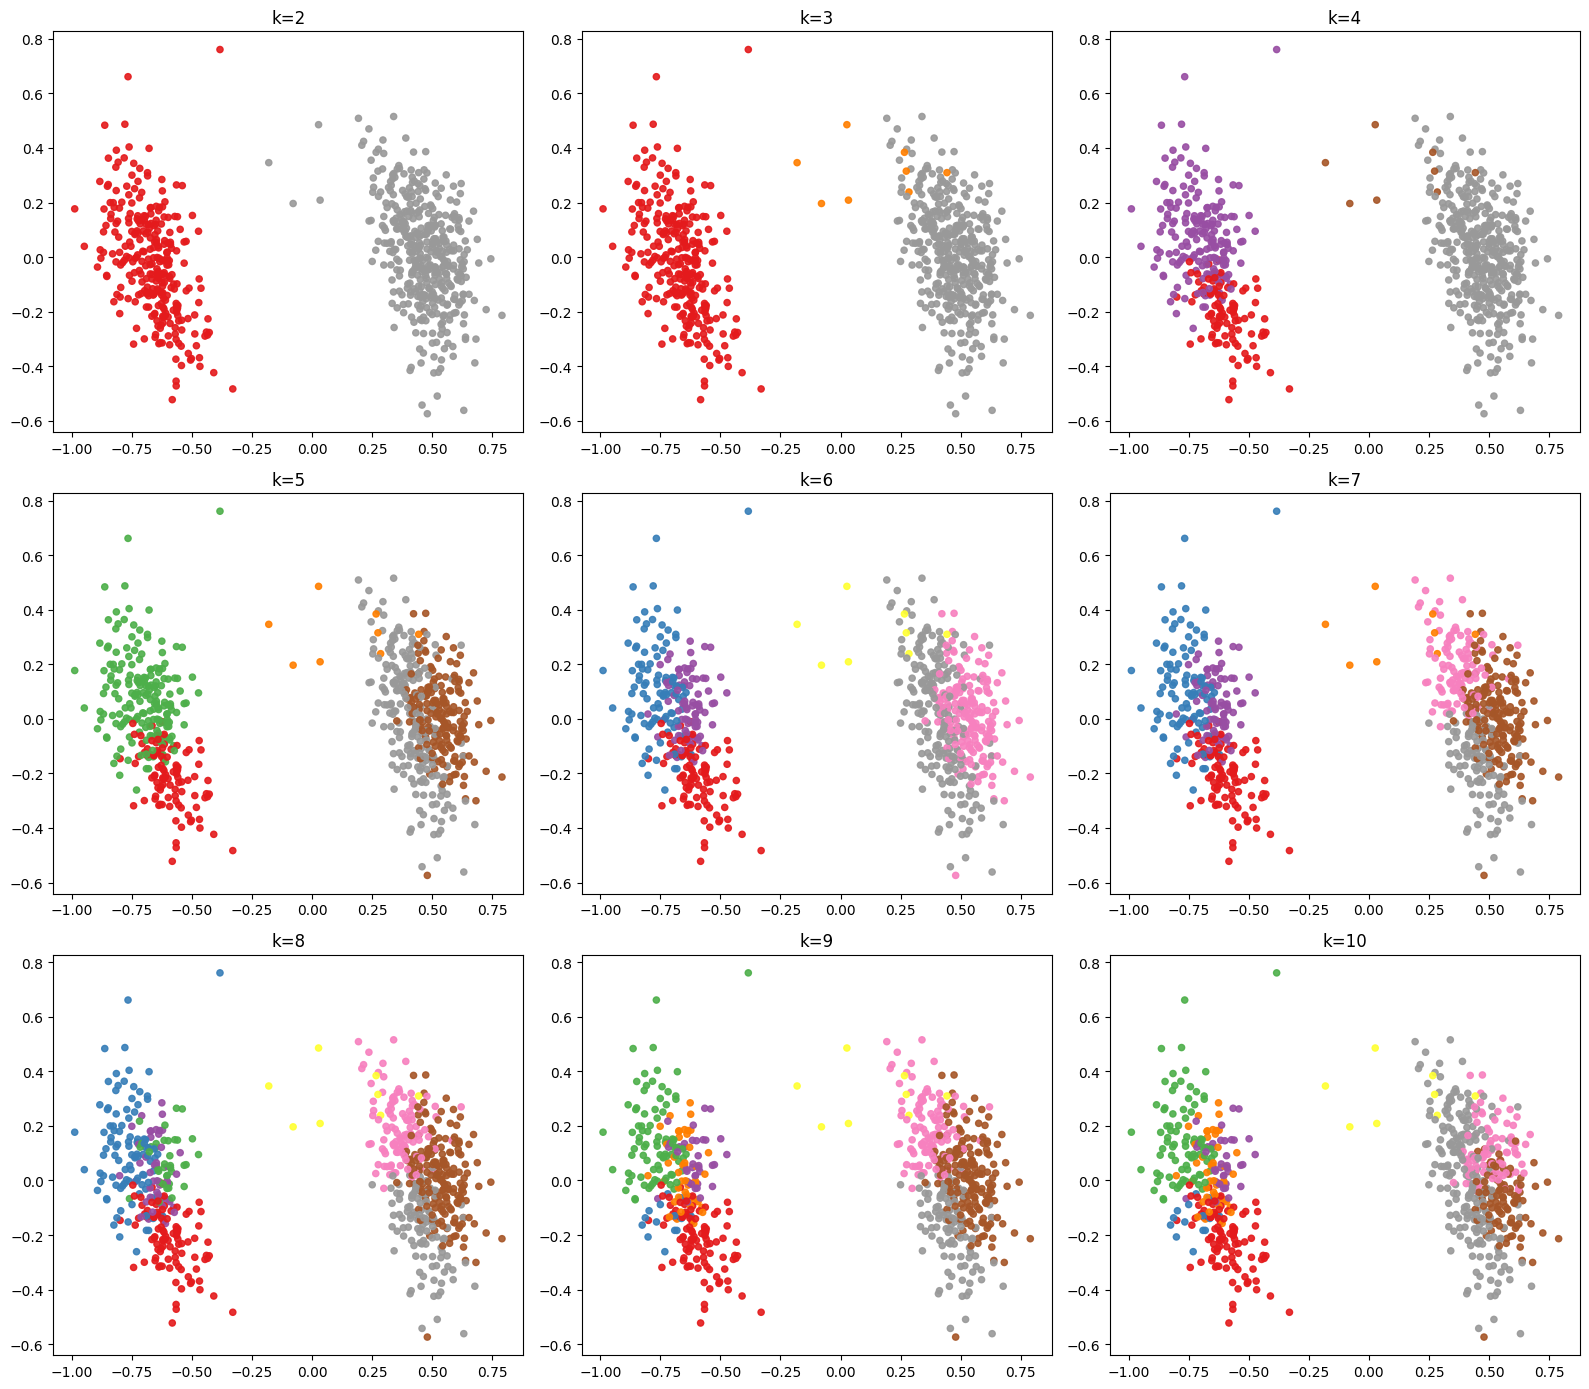

In [ ]:
pca = PCA(n_components=2)
coords = pca.fit_transform(matrix_to_cluster)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for ax, k in zip(axes.flatten(), range(2, 11)):
    th = [x[2] for x in link_matrix][-k]
    labels = sch.fcluster(link_matrix, th, criterion="distance")

    ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="Set1", s=20, alpha=0.9)
    ax.set_title(f"k={k}")

plt.tight_layout()
plt.show()

In [ ]:
final_k = best_k

th = [x[2] for x in link_matrix][-final_k]
labels = sch.fcluster(link_matrix, th, criterion="distance")

cluster_id_df = pd.DataFrame(index=matrix_to_cluster.index)
cluster_id_df[f"k={final_k}"] = labels

cluster_id_df.to_csv(f"{prefix}cluster_id_k{final_k}.tsv", sep="\t")

# Enrichment analysis

In [ ]:
clusters = cluster_id_df.reset_index()
clusters.columns = ["Gene", "Cluster"]

clusters["Gene"] = clusters["Gene"].astype(str).str.strip()

print("Cluster sizes:")
print(clusters["Cluster"].value_counts().sort_index())

display(clusters.head())

Cluster sizes:
Cluster
1    101
2     99
3     37
4     45
5      8
6    181
7    106
8    109
Name: count, dtype: int64


,Gene,Cluster
0,LAS1L,1
1,IBTK,6
2,TMEM98,6
3,DNAJC11,2
4,CELSR3,2


Merged table shape:
(686, 7)


,Gene,Cluster,SBS1,SBS2,SBS5,SBS13,SBS39
0,LAS1L,1,0.205698,0.006263,0.332773,0.031980,-0.463035
1,IBTK,6,-0.035381,-0.051175,-0.254968,-0.142950,0.464466
2,TMEM98,6,-0.193905,-0.093046,-0.153164,-0.147843,0.533886
3,DNAJC11,2,0.159443,0.267329,0.110670,0.232424,-0.543010
4,CELSR3,2,0.309083,0.095551,0.285234,0.196075,-0.460351


,SBS1,SBS2,SBS5,SBS13,SBS39
Cluster,,,,,
1,0.195158,0.008284,0.043940,0.009381,-0.506770
2,0.191369,0.308596,0.086824,0.305227,-0.512376
3,0.034633,0.144621,-0.172426,0.133385,-0.518213
4,-0.019148,0.176589,0.099783,0.208340,-0.514397
5,-0.149348,0.019074,-0.657528,-0.036119,0.121559
6,-0.205458,-0.186707,-0.185254,-0.170378,0.515247
7,-0.106930,0.042248,-0.045024,0.065153,0.510948
8,-0.047366,-0.199296,0.105568,-0.180196,0.506508


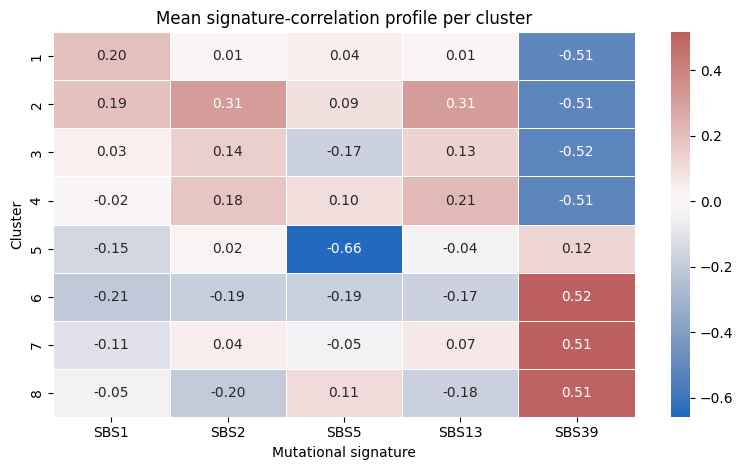

In [ ]:
# CHARACTERIZE CLUSTERS BY SIGNATURE-CORRELATION PROFILES
corr = corr_count.copy()
corr = corr_count.astype(float)
corr_reset = corr.reset_index()
corr_reset = corr_reset.rename(columns={corr_reset.columns[0]: "Gene"})

merged = clusters.merge(corr_reset, on="Gene", how="inner")

print("Merged table shape:")
print(merged.shape)

display(merged.head())

signature_cols = [col for col in merged.columns if col not in ["Gene", "Cluster"]]
cluster_means = merged.groupby("Cluster")[signature_cols].mean()

display(cluster_means)

plt.figure(figsize=(8, 4.8))
sns.heatmap(cluster_means, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5)

plt.title("Mean signature-correlation profile per cluster")
plt.xlabel("Mutational signature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig(f"{prefix}cluster_mean_correlation_heatmap_k{final_k}.png", dpi=300)
plt.show()

In [ ]:
background_genes = corr.index.astype(str).str.strip().unique().tolist()

print("Background genes:", len(background_genes))
print("Cluster sizes:")
print(clusters["Cluster"].value_counts().sort_index())

all_results = []

for cl in sorted(clusters["Cluster"].unique()):
    gene_list = (
        clusters.loc[clusters["Cluster"] == cl, "Gene"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    print(f"\nRunning enrichment for Cluster {cl}: {len(gene_list)} genes")

    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets="GO_Biological_Process_2026",
        organism="human",
        background=background_genes,
        outdir=None
    )

    res = enr.results.copy()
    res["Cluster"] = cl
    res["N_genes_in_cluster"] = len(gene_list)

    all_results.append(res)

    time.sleep(2)

all_go = pd.concat(all_results, ignore_index=True)
all_go = all_go.sort_values(["Cluster", "Adjusted P-value"])

all_go.to_csv(
    f"{prefix}GO_enrichment_all_clusters_k{final_k}_with_custom_background.tsv",
    sep="\t",
    index=False
)

sig_go = all_go[all_go["Adjusted P-value"] < 0.05].copy()

print("Significant GO terms, FDR < 0.05:", sig_go.shape[0])

display(
    sig_go[
        ["Cluster", "Gene_set", "Term", "Adjusted P-value", "Genes"]
    ].sort_values(["Cluster", "Adjusted P-value"]).head(100)
)

Background genes: 32597
Cluster sizes:
Cluster
1    101
2     99
3     37
4     45
5      8
6    181
7    106
8    109
Name: count, dtype: int64

Running enrichment for Cluster 1: 101 genes

Running enrichment for Cluster 2: 99 genes

Running enrichment for Cluster 3: 37 genes

Running enrichment for Cluster 4: 45 genes

Running enrichment for Cluster 5: 8 genes

Running enrichment for Cluster 6: 181 genes

Running enrichment for Cluster 7: 106 genes

Running enrichment for Cluster 8: 109 genes
Significant GO terms, FDR < 0.05: 30


,Cluster,Gene_set,Term,Adjusted P-value,Genes
617,2,GO_Biological_Process_2026,Maturation of 5.8S rRNA (GO:0000460),0.013097,EIF6;PES1;URB1
618,2,GO_Biological_Process_2026,TRNA Modification (GO:0006400),0.013097,MOCS3;METTL1;WDR4;PUSL1
619,2,GO_Biological_Process_2026,Maturation of LSU-rRNA (GO:0000470),0.013097,EIF6;PES1;URB1
620,2,GO_Biological_Process_2026,Ribosome Biogenesis (GO:0042254),0.027790,RRP7A;TCOF1;EIF6;PES1;NOC2L
621,2,GO_Biological_Process_2026,Regulation of Gluconeogenesis (GO:0006111),0.027790,ZNF692;KAT2A;MST1
622,2,GO_Biological_Process_2026,Aflatoxin Metabolic Process (GO:0046222),0.027790,AKR7A3;AKR7L
623,2,GO_Biological_Process_2026,Regulation of Translation (GO:0006417),0.037317,TCOF1;EIF6;PKP3;EIF3B;EIF4G1
624,2,GO_Biological_Process_2026,Ribosomal Large Subunit Biogenesis (GO:0042273),0.037317,EIF6;PES1;NOC2L
625,2,GO_Biological_Process_2026,Ribonucleoprotein Complex Biogenesis (GO:0022613),0.040407,RRP7A;TCOF1;PES1;NOC2L
626,2,GO_Biological_Process_2026,Regulation of Multicellular Organismal Develop...,0.049019,LAMA5;KAT2A;PKP3


In [ ]:
# SIGNIFICANT GO TERMS

sig_go = all_go[all_go["Adjusted P-value"] < 0.05].copy()

print("Number of significant terms, FDR < 0.05:", sig_go.shape[0])

if sig_go.empty:
    print("No significant GO terms at FDR < 0.05.")
else:
    sig_go = sig_go.sort_values(["Cluster", "Adjusted P-value"])

    display(
        sig_go[
            ["Cluster", "Gene_set", "Term", "Adjusted P-value", "Genes"]
        ]
    )

    sig_go.to_csv(
        f"{prefix}GO_enrichment_significant_FDR005_k{final_k}.tsv",
        sep="\t",
        index=False
    )

Number of significant terms, FDR < 0.05: 30


,Cluster,Gene_set,Term,Adjusted P-value,Genes
617,2,GO_Biological_Process_2026,Maturation of 5.8S rRNA (GO:0000460),0.013097,EIF6;PES1;URB1
618,2,GO_Biological_Process_2026,TRNA Modification (GO:0006400),0.013097,MOCS3;METTL1;WDR4;PUSL1
619,2,GO_Biological_Process_2026,Maturation of LSU-rRNA (GO:0000470),0.013097,EIF6;PES1;URB1
620,2,GO_Biological_Process_2026,Ribosome Biogenesis (GO:0042254),0.027790,RRP7A;TCOF1;EIF6;PES1;NOC2L
621,2,GO_Biological_Process_2026,Regulation of Gluconeogenesis (GO:0006111),0.027790,ZNF692;KAT2A;MST1
622,2,GO_Biological_Process_2026,Aflatoxin Metabolic Process (GO:0046222),0.027790,AKR7A3;AKR7L
623,2,GO_Biological_Process_2026,Regulation of Translation (GO:0006417),0.037317,TCOF1;EIF6;PKP3;EIF3B;EIF4G1
624,2,GO_Biological_Process_2026,Ribosomal Large Subunit Biogenesis (GO:0042273),0.037317,EIF6;PES1;NOC2L
625,2,GO_Biological_Process_2026,Ribonucleoprotein Complex Biogenesis (GO:0022613),0.040407,RRP7A;TCOF1;PES1;NOC2L
626,2,GO_Biological_Process_2026,Regulation of Multicellular Organismal Develop...,0.049019,LAMA5;KAT2A;PKP3


In [ ]:
# TOP GO TERMS PER CLUSTER

for cl in sorted(all_go["Cluster"].unique()):

    print("\n" + "="*90)
    print(f"CLUSTER {cl}")
    print("="*90)

    sub = all_go[all_go["Cluster"] == cl].copy()
    sub = sub.sort_values("Adjusted P-value")

    display(
        sub[
            ["Gene_set", "Term", "P-value", "Adjusted P-value", "Genes"]
        ].head(10)
    )


CLUSTER 1


,Gene_set,Term,P-value,Adjusted P-value,Genes
0,GO_Biological_Process_2026,Chromatin Organization (GO:0006325),0.000838,0.165981,SETD4;MAU2;HDAC10;DNTTIP1;BRCA1;TOP1
1,GO_Biological_Process_2026,Homologous Recombination (GO:0035825),0.001921,0.165981,HDAC10;BRCA1
2,GO_Biological_Process_2026,Regulation of Cell Cycle (GO:0051726),0.003560,0.165981,RNF123;AKT2;CDK5RAP1;RPRD1B;BRCA1
3,GO_Biological_Process_2026,Protein Maturation (GO:0051604),0.004714,0.165981,RNF123;HM13;ACTMAP;PMPCA
4,GO_Biological_Process_2026,Negative Regulation of Transport (GO:0051051),0.005899,0.165981,LRSAM1;ERBB3
5,GO_Biological_Process_2026,Protein Ubiquitination (GO:0016567),0.005973,0.165981,RNF123;LRSAM1;ARRDC1;ARIH2;BRCA1
6,GO_Biological_Process_2026,Positive Regulation of DNA-templated Transcrip...,0.006593,0.165981,MAP2K3;SETD4;SOX18;SERPINF2;KMT2B;RPRD1B;QRICH...
7,GO_Biological_Process_2026,Intrinsic Apoptotic Signaling Pathway (GO:0097...,0.006677,0.165981,QRICH1;BRCA1;IKBKE
8,GO_Biological_Process_2026,Phosphatidylinositol Phosphate Biosynthetic Pr...,0.006867,0.165981,ITPKC;PIK3C2B
25,GO_Biological_Process_2026,Cardiac Endothelial Cell Differentiation (GO:0...,0.015397,0.165981,SOX18



CLUSTER 2


,Gene_set,Term,P-value,Adjusted P-value,Genes
617,GO_Biological_Process_2026,Maturation of 5.8S rRNA (GO:0000460),0.000021,0.013097,EIF6;PES1;URB1
618,GO_Biological_Process_2026,TRNA Modification (GO:0006400),0.000059,0.013097,MOCS3;METTL1;WDR4;PUSL1
619,GO_Biological_Process_2026,Maturation of LSU-rRNA (GO:0000470),0.000060,0.013097,EIF6;PES1;URB1
620,GO_Biological_Process_2026,Ribosome Biogenesis (GO:0042254),0.000180,0.027790,RRP7A;TCOF1;EIF6;PES1;NOC2L
622,GO_Biological_Process_2026,Aflatoxin Metabolic Process (GO:0046222),0.000253,0.027790,AKR7A3;AKR7L
621,GO_Biological_Process_2026,Regulation of Gluconeogenesis (GO:0006111),0.000212,0.027790,ZNF692;KAT2A;MST1
624,GO_Biological_Process_2026,Ribosomal Large Subunit Biogenesis (GO:0042273),0.000452,0.037317,EIF6;PES1;NOC2L
623,GO_Biological_Process_2026,Regulation of Translation (GO:0006417),0.000406,0.037317,TCOF1;EIF6;PKP3;EIF3B;EIF4G1
625,GO_Biological_Process_2026,Ribonucleoprotein Complex Biogenesis (GO:0022613),0.000551,0.040407,RRP7A;TCOF1;PES1;NOC2L
626,GO_Biological_Process_2026,Regulation of Multicellular Organismal Develop...,0.000743,0.049019,LAMA5;KAT2A;PKP3



CLUSTER 3


...

,Gene_set,Term,P-value,Adjusted P-value,Genes
1951,GO_Biological_Process_2026,Positive Regulation of Cell Projection Organiz...,2.579134e-07,0.000239,TIAM2;CARMIL1;NTRK2;LRRC7;CAPRIN2;DMD;SERPINI1...
1952,GO_Biological_Process_2026,Positive Regulation of Neuron Projection Devel...,1.859431e-05,0.006054,NTRK2;LRRC7;CAPRIN2;DMD;SERPINI1;DDR2
1953,GO_Biological_Process_2026,Positive Regulation of Receptor Recycling (GO:...,1.963360e-05,0.006054,POPDC1;INPP5F;SNCA
1954,GO_Biological_Process_2026,Positive Regulation of Signaling (GO:0023056),4.713726e-05,0.010900,POPDC1;INPP5F;SORCS3;SNCA
1955,GO_Biological_Process_2026,Regulation of Receptor Recycling (GO:0001919),1.292095e-04,0.023904,POPDC1;INPP5F;SNCA
1956,GO_Biological_Process_2026,Regulation of Transcription by RNA Polymerase ...,3.138162e-04,0.048380,ZNF396;CSRNP3;ZSCAN9;RAX;ZBTB20;RORB;NPAS3;PGB...
1957,GO_Biological_Process_2026,Regulation of Neuron Projection Development (G...,4.973487e-04,0.065721,CCDC88A;NTRK2;LRRC7;DMD;SERPINI1;DDR2
1958,GO_Biological_Process_2026,Lamellipodium Organization (GO:0097581),6.749797e-04,0.076238,CARMIL1;CCDC88A;SNX2
1959,GO_Biological_Process_2026,Positive Regulation of Macromolecule Metabolic...,7.417767e-04,0.076238,POPDC1;INPP5F;SNCA
1960,GO_Biological_Process_2026,Positive Regulation of Vesicle Fusion (GO:0031...,1.075885e-03,0.088786,C2CD5;SNCA



CLUSTER 7


,Gene_set,Term,P-value,Adjusted P-value,Genes
2876,GO_Biological_Process_2026,Regulation of Neuron Differentiation (GO:0045664),0.000087,0.039862,PCP4;ROCK1;MMD;NREP
2877,GO_Biological_Process_2026,Positive Regulation of Voltage-Gated Calcium C...,0.000104,0.039862,STAC;STAC2
2878,GO_Biological_Process_2026,Activation of Protein Kinase B Activity (GO:00...,0.000290,0.047430,NRG1;FGF1
2879,GO_Biological_Process_2026,Nervous System Development (GO:0007399),0.000313,0.047430,NRSN1;PTPRZ1;CDH2;CNTN6;NRG1;JRKL;FGF1;MDGA2
2880,GO_Biological_Process_2026,Regulation of Voltage-Gated Calcium Channel Ac...,0.000372,0.047430,STAC;STAC2
2881,GO_Biological_Process_2026,Regulation of Morphogenesis of an Epithelium (...,0.000372,0.047430,GJA1;FGF1
2889,GO_Biological_Process_2026,DNA Double-Strand Break Processing (GO:0000729),0.001380,0.075498,RBBP8;SETMAR
2883,GO_Biological_Process_2026,Atrial Cardiac Muscle Cell Action Potential (G...,0.000798,0.075498,GJA1;KCNN2
2885,GO_Biological_Process_2026,G Protein-Coupled Dopamine Receptor Signaling ...,0.001220,0.075498,FLNA;RGS9
2886,GO_Biological_Process_2026,Regulation of Stem Cell Proliferation (GO:0072...,0.001380,0.075498,YAP1;GJA1



CLUSTER 8


,Gene_set,Term,P-value,Adjusted P-value,Genes
3642,GO_Biological_Process_2026,Modulation of Chemical Synaptic Transmission (...,0.001383,0.226115,LGI1;GRIA1;GRIA2;C1QL1
3643,GO_Biological_Process_2026,Regulation of Telomere Maintenance via Telomer...,0.001825,0.226115,DHX36;POT1
3676,GO_Biological_Process_2026,Glucosylceramide Metabolic Process (GO:0006678),0.026443,0.226115,B3GALT1
3677,GO_Biological_Process_2026,Spindle Assembly Involved in Female Meiosis (G...,0.026443,0.226115,SKA2
3678,GO_Biological_Process_2026,Negative Regulation of Voltage-Gated Potassium...,0.026443,0.226115,LGI1
3679,GO_Biological_Process_2026,Regulation of Intracellular mRNA Localization ...,0.026443,0.226115,DHX36
3680,GO_Biological_Process_2026,Telomeric D-loop Disassembly (GO:0061820),0.026443,0.226115,POT1
3681,GO_Biological_Process_2026,Meiotic Spindle Assembly (GO:0090306),0.026443,0.226115,SKA2
3682,GO_Biological_Process_2026,MiRNA-mediated Gene Silencing by mRNA Destabil...,0.026443,0.226115,AGO4
3683,GO_Biological_Process_2026,Regulation of Protein Autophosphorylation (GO:...,0.026443,0.226115,EPHA7


In [ ]:
import re

cluster_order = list(cluster_means.index)

cluster_sizes = (
    clusters["Cluster"]
    .value_counts()
    .sort_index()
    .reindex(cluster_order)
)

def clean_term(term):
    term = str(term)
    term = re.sub(r"\s*\(GO:\d+\)", "", term)
    return term

manual_terms = {
    1: [],
    2: ["Ribosome biogenesis",
        "rRNA maturation",
        "Translation"],
    3: [
        "Glycoprotein and glycolipid metabolism"],
    4: [],
    5: ["Transcriptional regulation",
        "Cell cycle and G1/S transition"],
    6: ["Cell projection organization and development",
    "Receptor recycling and cellular signaling"],
    7: ["Developmental differentiation and morphogenesis",
        "Calcium channel and protein kinase B activity"],
    8: [],
}

landmark_terms = {}
line_counts = {}

for cl in cluster_order:
    top_terms = manual_terms.get(cl, [])

    if top_terms:
        txt = "\n".join(top_terms)
        landmark_terms[cl] = txt
        line_counts[cl] = len(top_terms)
    else:
        landmark_terms[cl] = "—"
        line_counts[cl] = 1

summary_df = pd.DataFrame({
    "Cluster": cluster_order,
    "n_genes": cluster_sizes.values,
    "landmark_terms": [landmark_terms[cl] for cl in cluster_order],
    "n_lines": [line_counts[cl] for cl in cluster_order]
})

display(summary_df)

,Cluster,n_genes,landmark_terms,n_lines
0,1,101,—,1
1,2,99,Ribosome biogenesis\nrRNA maturation\nTranslation,3
2,3,37,Glycoprotein and glycolipid metabolism,1
3,4,45,—,1
4,5,8,Transcriptional regulation\nCell cycle and G1/...,2
5,6,181,Cell projection organization and development\n...,2
6,7,106,Developmental differentiation and morphogenesi...,2
7,8,109,—,1


/tmp/ipykernel_2346/729648764.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


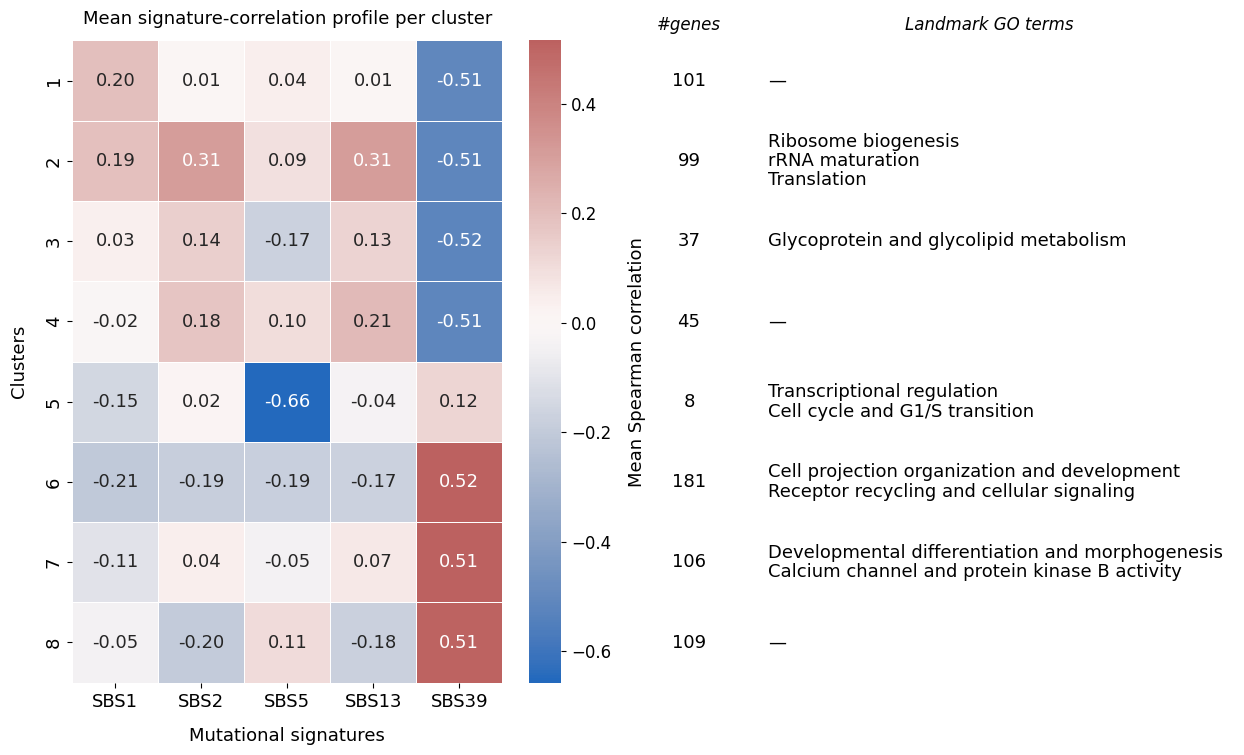

In [ ]:
from matplotlib.gridspec import GridSpec

plot_cluster_means = cluster_means.loc[cluster_order]

base_height = 0.75 * len(cluster_order)
extra_height = 0.18 * summary_df["n_lines"].sum()
fig_height = max(6, base_height + extra_height)

fig = plt.figure(figsize=(15, fig_height))
gs = GridSpec(1, 3, width_ratios=[3.5, 0.4, 3.2], wspace=0.10)

# Heatmap
ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(
    plot_cluster_means,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Spearman correlation"},
    ax=ax0,
    annot_kws={"fontsize": 13.0},
)


cbar = ax0.collections[0].colorbar
cbar.set_label("Mean Spearman correlation", fontsize=13, labelpad=12)
cbar.ax.tick_params(labelsize=12)
ax0.set_title("Mean signature-correlation profile per cluster", pad=12, fontsize=13)
ax0.set_xlabel("Mutational signatures", fontsize=13, labelpad=12)
ax0.set_ylabel("Clusters", fontsize=13, labelpad=12)
ax0.tick_params(axis="x", labelsize=13)
ax0.tick_params(axis="y", labelsize=13)

# Number of genes
ax1 = fig.add_subplot(gs[0, 1])
ax1.set_xlim(0, 1)
ax1.set_ylim(ax0.get_ylim())
ax1.axis("off")
ax1.set_title("#genes", fontstyle="italic", pad=8, x=0.7)

for i, cl in enumerate(cluster_order):
    ax1.text(
        0.7, i + 0.5,
        str(summary_df.loc[summary_df["Cluster"] == cl, "n_genes"].values[0]),
        ha="center", va="center", fontsize=13
    )

# Landmark GO terms
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_xlim(0, 1)
ax2.set_ylim(ax0.get_ylim())
ax2.axis("off")
ax2.set_title("Landmark GO terms", fontstyle="italic", pad=8)

for i, cl in enumerate(cluster_order):
    txt = summary_df.loc[summary_df["Cluster"] == cl, "landmark_terms"].values[0]
    ax2.text(
        0.05, i + 0.5,
        txt,
        ha="left",
        va="center",
        fontsize=13.0,
        linespacing=1.1
    )

plt.tight_layout()
plt.savefig(f"{prefix}cluster_summary_GO_k{final_k}.png", dpi=300, bbox_inches="tight")
plt.show()